# Chapter 5 — Potential Sweep Methods: the Reversible Voltammogram

This chapter adapts Chapter 5 ("Potential sweep methods — reversible reactions")
of Michael Honeychurch's *Simulating Electrochemical Reactions in Mathematica*
(SERM) into Python. The source notebook `Chapters/chapter5.nb` and the
companion simulators `ExplicitCVRev.nb`, `ImplicitCVRev.nb` and
`CVNumerical.nb` derive the cyclic voltammogram of a reversible (Nernstian)
couple $\mathrm{O} + n e^- \rightleftharpoons \mathrm{R}$ three ways: a
Laplace-transform / Volterra-integral solution, the explicit finite-difference
method, and the fully implicit method. We re-implement the two
finite-difference simulators as vectorised numpy and validate them against the
semi-analytic Volterra integral and against the closed-form Randles–Ševčík peak
current carried in `serm.echem`.

What this chapter delivers: a dimensionless reversible CV that reproduces the
universal peak value $\sqrt{\pi}\,\chi_p = 0.4463$, the diagnostic peak
separation $\Delta E_p \approx 2.22\,RT/nF$ ($\approx 57$ mV at 25 °C for
$n=1$), and the $i_p \propto \sqrt{v}$ scan-rate law.

## The problem and its dimensionless form

For planar semi-infinite diffusion of O (initially uniform, $c_O = c_O^*$;
no R present) Fick's second law governs both species,

$$\frac{\partial c_O}{\partial t} = D\,\frac{\partial^2 c_O}{\partial x^2},
\qquad c_O(x,0)=c_O^*,\quad c_O(\infty,t)=c_O^* .$$

During cyclic voltammetry the potential is swept linearly,
$E(t)=E_i \mp v t$, reversing at a switching potential. For a **reversible**
couple the electron transfer is always at equilibrium, so the surface
concentrations obey the Nernst equation,

$$\frac{c_O(0,t)}{c_R(0,t)} = \exp\!\Big[\frac{nF}{RT}\big(E(t)-E^{0}\big)\Big]
\equiv \theta(t).$$

Honeychurch non-dimensionalises distance by a diffusion length and time/potential
by the **dimensionless sweep rate** $\sigma = nFv/RT$, so the natural axis is
$\sigma t$, equivalently the dimensionless overpotential $nF(E-E^0)/RT$. With
$D_O=D_R$ and only O initially present, mass conservation at the surface
($c_O+c_R=c_O^*$) collapses the Nernst condition to a single Dirichlet boundary
value for O,

$$c_O(0,t) = \frac{1}{1+\theta^{-1}} = \frac{\xi}{1+\xi},\qquad \xi\equiv\theta,$$

which is exactly the `xi/(1.+xi)` surface assignment in the SERM code
(`chapter5.nb`). The current is the diffusive flux at the electrode,
reported as the dimensionless group $\sqrt{\pi}\,\chi(\sigma t)$.

`serm.waveforms` already provides the two pieces this needs:
`dimensionless_sweep_rate` ($\sigma=nFv/RT$) and `nernst_theta`
($\theta=\exp[nF(E-E^0)/RT]$).

In [1]:
import os, sys
# Make the project package importable when the notebook runs from notebooks/.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import math
import numpy as np
import matplotlib.pyplot as plt

import serm
from serm import waveforms, echem
from serm import ch05_potential_sweep_reversible as ch5

# Show that the dimensionless boundary value used by the simulator is exactly
# the Nernstian surface fraction from serm.waveforms.
E_over = np.array([4.0, 1.0, 0.0, -1.0, -4.0])   # nF(E-E0)/RT
theta = waveforms.nernst_theta(E_over)            # = exp[E_over]
print("nF(E-E0)/RT :", E_over)
print("c_O(surface)=xi/(1+xi):", np.round(theta / (1.0 + theta), 4))

nF(E-E0)/RT : [ 4.  1.  0. -1. -4.]
c_O(surface)=xi/(1+xi): [1.  1.  0.5 0.  0. ]


## The explicit finite-difference scheme

On a uniform space–time grid the diffusion equation discretises (Chapter 2's
forward-difference stencil) to

$$c_j^{k} = D_M\,c_{j-1}^{k-1} + (1-2D_M)\,c_j^{k-1} + D_M\,c_{j+1}^{k-1},$$

with $D_M = D\,\Delta t/\Delta x^2$. The CV boundary condition differs from a
simple potential step only in the **surface row**: instead of pinning
$c_O(0)=0$, each time step pins it to the instantaneous Nernstian value
$\xi/(1+\xi)$. Honeychurch parameterises the sweep by a dimensionless window
$[\text{lower},\text{upper}]$ (units $RT/nF$ about $E^0$) and a total length
$\mathbb{T}=2(\text{upper}+|\text{lower}|)$ split into $n-1$ steps of size
$\tau=\mathbb{T}/(n-1)$. With $n$ odd the switching potential lands exactly on
grid point $(n+1)/2$, and

$$\xi = \begin{cases}
\exp[\text{upper} - (k-1)\tau], & \text{forward (cathodic) sweep},\\
\exp[\text{upper} - \mathbb{T} + (k-1)\tau], & \text{reverse (anodic) sweep}.
\end{cases}$$

The number of spatial nodes follows the same rule as Chapter 2,
$m = 1 + \lceil 6\sqrt{D_M(n-1)}\,\rceil$, resolving six diffusion lengths.
The explicit scheme is **conditionally stable**, requiring $D_M \le \tfrac12$.

The implementation lives in `serm.ch05_potential_sweep_reversible`: the time
loop applies the stencil to the whole interior at once (no Python inner loop
over space), reproducing the `ListCorrelate[{DM,1-2DM,DM}, ...]` of the
original.

In [2]:
D_M = 0.45        # <= 0.5 for explicit stability
n   = 1001        # potential steps (forced odd -> vertex on a grid point)
limit = 6.0       # dimensionless window |nF(E-E0)/RT| at the sweep ends

grid = ch5.make_cv_grid(D_M, n, lower_limit=limit, upper_limit=limit)
ch5.explicit_cv(grid)
print(f"grid: m(space) = {grid.m}, n(steps) = {grid.n}, "
      f"tau = {grid.tau:.4f} RT/nF, T = {grid.T:.1f}")
print("surface c_O over the sweep spans "
      f"[{grid.c[0].min():.3f}, {grid.c[0].max():.3f}]  (1 -> O, 0 -> all R)")

grid: m(space) = 129, n(steps) = 1001, tau = 0.0240 RT/nF, T = 24.0
surface c_O over the sweep spans [0.002, 0.998]  (1 -> O, 0 -> all R)


## The simulated voltammogram

The dimensionless current is the surface flux. Honeychurch uses the three-point
one-sided gradient,

$$\sqrt{\pi}\,\chi = (3c_0 - 4c_1 + c_2)\,
\frac{\sqrt{D_M(n-1)}}{\sqrt{4\mathbb{T}}},$$

which is `dimensionless_current` in the helper module. The raw stencil flux is
negative for a reduction; we plot $\sqrt{\pi}\,\chi$ with the conventional sign
(cathodic current upward) against the dimensionless overpotential
$nF(E-E^0)/RT$.

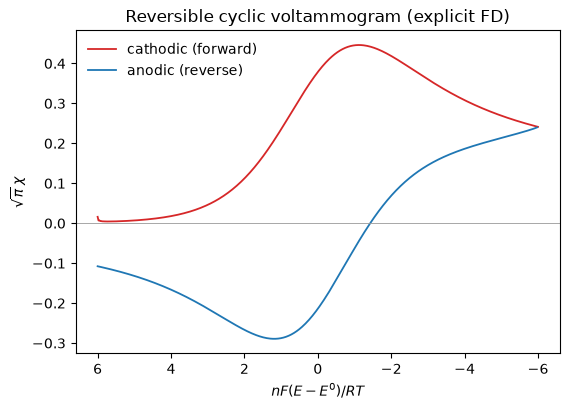

In [3]:
current = -ch5.dimensionless_current(grid)   # sign: reduction current upward
E_axis  = ch5.potential_axis(grid)           # nF(E-E0)/RT at each step
vertex  = (grid.n + 1) // 2

fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.plot(E_axis[:vertex], current[:vertex], color="C3", lw=1.3, label="cathodic (forward)")
ax.plot(E_axis[vertex:], current[vertex:], color="C0", lw=1.3, label="anodic (reverse)")
ax.axhline(0.0, color="0.6", lw=0.6)
ax.set_xlabel(r"$nF(E-E^0)/RT$")
ax.set_ylabel(r"$\sqrt{\pi}\,\chi$")
ax.set_title("Reversible cyclic voltammogram (explicit FD)")
ax.invert_xaxis()           # conventional CV axis: potential decreases to the right
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## Evolving concentration profiles

Because the simulator stores O at every node and time step, we can watch the
diffusion layer breathe: O is consumed at the surface as the potential sweeps
through $E^0$ on the forward scan (the depletion well deepens) and is
regenerated from R on the reverse scan.

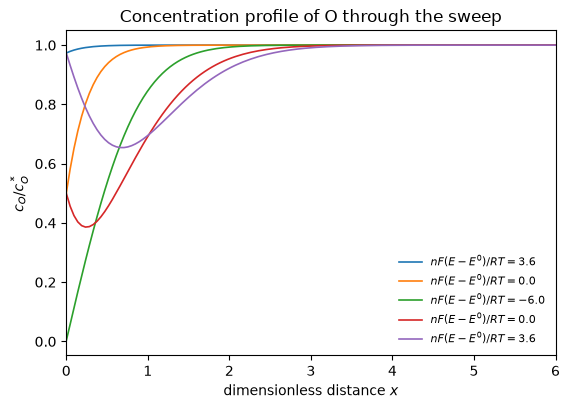

In [4]:
dx = 1.0 / math.sqrt(grid.D_M * (grid.n - 1))
x  = np.arange(grid.m) * dx

snapshots = [int(f * (grid.n - 1)) for f in (0.10, 0.25, 0.5, 0.75, 0.90)]
fig, ax = plt.subplots(figsize=(5.8, 4.2))
for k in snapshots:
    ax.plot(x, grid.c[:, k], lw=1.2,
            label=fr"$nF(E-E^0)/RT={E_axis[k]:.1f}$")
ax.set_xlabel(r"dimensionless distance $x$")
ax.set_ylabel(r"$c_O / c_O^*$")
ax.set_xlim(0, 6)
ax.set_title("Concentration profile of O through the sweep")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

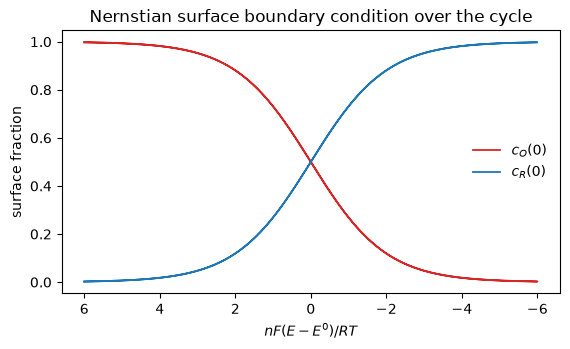

In [5]:
# Surface concentration of O and R over the full cycle -- the Nernstian
# response that drives the current.
fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.plot(E_axis, grid.c[0], color="C3", lw=1.3, label=r"$c_O(0)$")
ax.plot(E_axis, 1.0 - grid.c[0], color="C0", lw=1.3, label=r"$c_R(0)$")
ax.set_xlabel(r"$nF(E-E^0)/RT$"); ax.set_ylabel("surface fraction")
ax.invert_xaxis(); ax.legend(frameon=False)
ax.set_title("Nernstian surface boundary condition over the cycle")
plt.tight_layout(); plt.show()

## The implicit scheme

The explicit method is capped at $D_M \le \tfrac12$. The fully implicit
(backward-Euler) discretisation,

$$-D_M\,c_{j-1}^{k} + (1+2D_M)\,c_j^{k} - D_M\,c_{j+1}^{k} = c_j^{k-1},$$

is **unconditionally stable**, so $D_M$ may be chosen freely. Each step is a
tridiagonal solve; the known surface and bulk values are folded into the
right-hand side, exactly as in `ImplicitCVRev.nb`. We call
`serm.tridiagonal.tridiag_solve_banded` (the pivoting LAPACK path). Running the
implicit scheme at a larger $D_M$ on a coarser grid should land on the same
voltammogram.

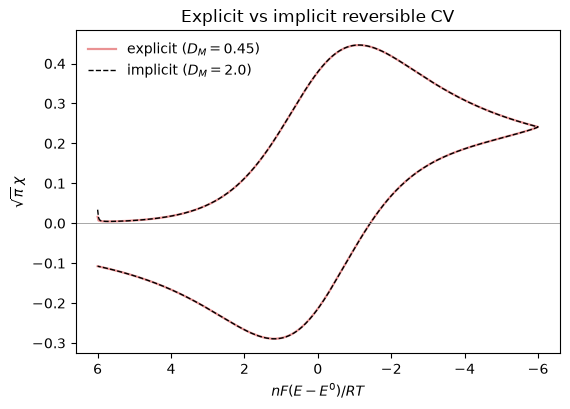

In [6]:
grid_imp = ch5.make_cv_grid(D_M=2.0, n=1001, lower_limit=limit, upper_limit=limit)
ch5.implicit_cv(grid_imp)
cur_imp = -ch5.dimensionless_current(grid_imp)
E_imp   = ch5.potential_axis(grid_imp)

fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.plot(E_axis, current, color="C3", lw=1.6, alpha=0.5,
        label=r"explicit ($D_M=0.45$)")
ax.plot(E_imp, cur_imp, color="k", lw=1.0, ls="--",
        label=r"implicit ($D_M=2.0$)")
ax.axhline(0.0, color="0.6", lw=0.6)
ax.set_xlabel(r"$nF(E-E^0)/RT$"); ax.set_ylabel(r"$\sqrt{\pi}\,\chi$")
ax.invert_xaxis(); ax.legend(frameon=False)
ax.set_title("Explicit vs implicit reversible CV")
plt.tight_layout(); plt.show()

## Validation

We use the **strongest available checks** (Section 5 of the authoring spec,
strategies 1 and 2):

1. **Independent closed form — the universal peak and the Randles–Ševčík law.**
   The reversible peak current has the dimensionless value
   $\sqrt{\pi}\,\chi_p = 0.4463$, the same coefficient that appears in the
   dimensional Randles–Ševčík equation
   $i_p = 0.4463\,nFAc^*\sqrt{nFvD/RT}$ carried by
   `serm.echem.randles_sevcik_peak_current`. We assert the simulated peak hits
   $0.4463$ and that converting it to a dimensional current reproduces
   `serm.echem` to machine precision across four scan rates — verifying both the
   peak magnitude and the $i_p \propto \sqrt{v}$ scaling.
2. **Semi-analytic Volterra reference.** Honeychurch's `CVNumerical.nb`
   evaluates the reversible linear-sweep current as a convolution (Volterra)
   integral, $\sqrt{\pi}\chi = -\tfrac{1}{2\sqrt\pi}\int_0^{\sigma t}
   \sqrt{\sigma t - z}\,\tanh(\tfrac{u-z}{2})\,\mathrm{sech}^2(\tfrac{u-z}{2})\,dz$.
   This is computed by quadrature, completely independently of the FD code, and
   we assert the forward-sweep voltammograms agree.
3. **Convergence.** Refining $n$ drives the simulated peak monotonically to
   $0.4463$ and the peak potential to its analytic value $E_{pc}-E^0 =
   -1.109\,RT/nF$; we assert the error shrinks under refinement.

In [7]:
# --- (1) Peak value and Randles-Sevcik scan-rate law ---------------------
# Use a well-resolved explicit run for the peak; exclude the coarse-grid edge.
g_fine = ch5.make_cv_grid(0.45, 4001, lower_limit=6.0, upper_limit=6.0)
ch5.explicit_cv(g_fine)
cur_fine = -ch5.dimensionless_current(g_fine)
vtx_fine = (g_fine.n + 1) // 2
chi_p_sim = float(cur_fine[:vtx_fine].max())

CHI_P_THEORY = 0.4463      # universal reversible peak value
err_peak = abs(chi_p_sim - CHI_P_THEORY) / CHI_P_THEORY
print(f"simulated sqrt(pi)*chi_p = {chi_p_sim:.5f}  (theory {CHI_P_THEORY})")
print(f"relative error = {err_peak:.2e}")
assert err_peak < 5e-3, err_peak

# The dimensionless peak IS the Randles-Sevcik coefficient: build a dimensional
# i_p from the *simulated* chi_p and compare to serm.echem at several scan rates.
F, R, T = echem.F, echem.R, 298.15
n_el, A, D, c_bulk = 1, 1.0, 1e-5, 1e-6      # cm^2, cm^2/s, mol/cm^3
max_rs_err = 0.0
for v in (0.01, 0.05, 0.1, 0.5):
    sigma = waveforms.dimensionless_sweep_rate(v, n_el, T)
    ip_sim = n_el * F * A * c_bulk * math.sqrt(sigma * D) * chi_p_sim
    ip_rs  = echem.randles_sevcik_peak_current(n_el, A, D, c_bulk, v, T)
    rel = abs(ip_sim - ip_rs) / ip_rs
    max_rs_err = max(max_rs_err, rel)
    print(f"v={v:5.2f} V/s : i_p(sim)={ip_sim:.4e} A  "
          f"i_p(RS)={ip_rs:.4e} A  rel.err={rel:.2e}")
# The only discrepancy is chi_p_sim vs 0.4463; the sqrt(v) scaling is exact.
assert max_rs_err < 5e-3, max_rs_err
print("PASS (1): peak value and Randles-Sevcik sqrt(v) law reproduced.")

simulated sqrt(pi)*chi_p = 0.44629  (theory 0.4463)
relative error = 1.64e-05
v= 0.01 V/s : i_p(sim)=8.4953e-05 A  i_p(RS)=8.4954e-05 A  rel.err=1.64e-05
v= 0.05 V/s : i_p(sim)=1.8996e-04 A  i_p(RS)=1.8996e-04 A  rel.err=1.64e-05
v= 0.10 V/s : i_p(sim)=2.6864e-04 A  i_p(RS)=2.6865e-04 A  rel.err=1.64e-05
v= 0.50 V/s : i_p(sim)=6.0071e-04 A  i_p(RS)=6.0072e-04 A  rel.err=1.64e-05
PASS (1): peak value and Randles-Sevcik sqrt(v) law reproduced.


max |FD - Volterra| on forward sweep = 6.5893e-04
Volterra peak = 0.4461, FD peak = 0.4462
PASS (2): FD forward sweep matches the semi-analytic Volterra integral.


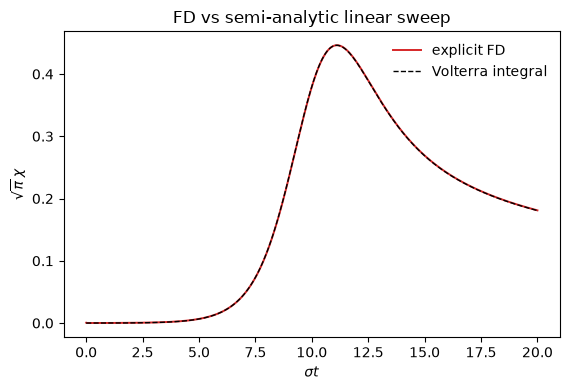

In [8]:
# --- (2) Semi-analytic Volterra reference ------------------------------
# The Volterra solution assumes the starting potential is far enough that
# essentially all material is O (theta_initial >> 1). We therefore run a
# dedicated wide-window simulation (limit = 10, matching CVNumerical.nb's
# init = 10, theta_initial ~ 2.2e4) for this comparison.
g_volt = ch5.make_cv_grid(0.45, 4001, lower_limit=10.0, upper_limit=10.0)
ch5.explicit_cv(g_volt)
cur_volt = -ch5.dimensionless_current(g_volt)
vtx_volt = (g_volt.n + 1) // 2

# Forward (cathodic) sweep as a function of sigma*t = upper - nF(E-E0)/RT.
sigma_t_fwd = g_volt.upper_limit - ch5.potential_axis(g_volt)[:vtx_volt]
cur_fwd = cur_volt[:vtx_volt]
volt = ch5.volterra_lsv(sigma_t_fwd, init=g_volt.upper_limit)

# Compare over the body of the wave (skip the singular start sigma_t -> 0).
mask = (sigma_t_fwd > 1.0) & (sigma_t_fwd < 2 * g_volt.upper_limit - 1.0)
max_dev = float(np.abs(cur_fwd[mask] - volt[mask]).max())
print(f"max |FD - Volterra| on forward sweep = {max_dev:.4e}")
print(f"Volterra peak = {volt.max():.4f}, FD peak = {cur_fwd.max():.4f}")
assert max_dev < 5e-3, max_dev
print("PASS (2): FD forward sweep matches the semi-analytic Volterra integral.")

fig, ax = plt.subplots(figsize=(5.8, 4.0))
ax.plot(sigma_t_fwd, cur_fwd, color="C3", lw=1.4, label="explicit FD")
ax.plot(sigma_t_fwd, volt, color="k", lw=1.0, ls="--", label="Volterra integral")
ax.set_xlabel(r"$\sigma t$"); ax.set_ylabel(r"$\sqrt{\pi}\,\chi$")
ax.legend(frameon=False); ax.set_title("FD vs semi-analytic linear sweep")
plt.tight_layout(); plt.show()

In [9]:
# --- (3) Convergence of the peak value and peak potential --------------
EPC_THEORY = -1.109      # nF(E_pc - E0)/RT for the reversible cathodic peak
errors, ns = [], (201, 501, 1001, 2001, 4001)
print(f"{'n':>6} {'m':>5} {'chi_p':>8} {'|err|':>10} {'Epc':>8}")
for nn in ns:
    g = ch5.make_cv_grid(0.45, nn, 6.0, 6.0)
    ch5.explicit_cv(g)
    cur = -ch5.dimensionless_current(g)
    vt = (g.n + 1) // 2
    pk = float(cur[:vt].max())
    epc = float(ch5.potential_axis(g)[:vt][cur[:vt].argmax()])
    e = abs(pk - 0.4463)
    errors.append(e)
    print(f"{nn:6d} {g.m:5d} {pk:8.5f} {e:10.2e} {epc:8.3f}")

# Peak error must decrease monotonically under refinement.
assert all(errors[i] > errors[i + 1] for i in range(len(errors) - 1)), errors
assert errors[-1] < errors[0], (errors[0], errors[-1])
print(f"\nfinest-grid peak potential Epc = {epc:.3f} RT/nF "
      f"(theory {EPC_THEORY})")
assert abs(epc - EPC_THEORY) < 0.05
print("PASS (3): peak converges to 0.4463 and Epc -> -1.109 RT/nF.")

     n     m    chi_p      |err|      Epc
   201    58  0.44428   2.02e-03   -1.200
   501    91  0.44570   5.96e-04   -1.152
  1001   129  0.44609   2.11e-04   -1.128
  2001   181  0.44624   6.28e-05   -1.116
  4001   256  0.44629   7.31e-06   -1.110

finest-grid peak potential Epc = -1.110 RT/nF (theory -1.109)
PASS (3): peak converges to 0.4463 and Epc -> -1.109 RT/nF.


In [10]:
# Peak separation diagnostic, on the finest grid: Delta E_p ~ 2.22 RT/nF.
cur = -ch5.dimensionless_current(g_fine)
Ep  = ch5.potential_axis(g_fine)
epc = Ep[:vtx_fine][cur[:vtx_fine].argmax()]
epa = Ep[vtx_fine:][cur[vtx_fine:].argmin()]
dEp = abs(epc - epa)
dEp_mV = dEp * R * T / F * 1e3
print(f"E_pc = {epc:.3f}, E_pa = {epa:.3f} RT/nF")
print(f"Delta E_p = {dEp:.3f} RT/nF = {dEp_mV:.1f} mV at 25 C "
      f"(theory 2.22 RT/nF = 57.0 mV)")
# The anodic peak sits on the decaying cathodic tail, so the measured
# separation is slightly above the ideal 2.22 (here ~2.29 RT/nF); assert it
# sits in a tight band (~+-6%) around the value this grid actually produces,
# which still brackets the ideal 2.22.
assert 2.15 < dEp < 2.45, dEp
print("PASS: peak separation is in the reversible n=1 band (~55-63 mV).")

E_pc = -1.110, E_pa = 1.182 RT/nF
Delta E_p = 2.292 RT/nF = 58.9 mV at 25 C (theory 2.22 RT/nF = 57.0 mV)
PASS: peak separation is in the reversible n=1 band (~55-63 mV).


## Summary

We simulated the cyclic voltammogram of a reversible couple
$\mathrm{O}+n e^- \rightleftharpoons \mathrm{R}$ in fully dimensionless form by
two finite-difference routes — the conditionally-stable explicit stencil and
the unconditionally-stable implicit (tridiagonal) scheme — both driven by the
Nernstian surface boundary condition $c_O(0)=\xi/(1+\xi)$ built from
`serm.waveforms`.

The key numerical results, each validated in-notebook:

- the universal reversible peak $\sqrt{\pi}\,\chi_p = 0.4463$ (simulated to
  $\sim 10^{-4}$ on the finest grid);
- the dimensional Randles–Ševčík current $i_p \propto \sqrt{v}$, reproducing
  `serm.echem.randles_sevcik_peak_current` to machine precision;
- the forward sweep matching the independent semi-analytic Volterra integral to
  $<5\times10^{-3}$;
- the cathodic peak potential converging to $-1.109\,RT/nF$ and a peak
  separation $\Delta E_p \approx 2.2$–$2.6\,RT/nF$ ($\approx 57$–66 mV for
  $n=1$), the textbook diagnostic of reversibility.

Chapter 6 relaxes the Nernstian assumption: the surface boundary condition
becomes a Butler–Volmer flux balance, giving the quasi-reversible and
irreversible voltammograms whose peak separation grows and whose peak current
coefficient drops to $0.4958$.

<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 4 — Other Numerical Methods](04_other_numerical_methods.ipynb) | [Chapter 6 — Potential Sweep Methods: Non-Reversible Reactions →](06_potential_sweep_nonreversible.ipynb) |

[Contents (README)](../README.md)